# GeoBench KuroSiwo

## Intro

KuroSiwo [(Bountos et al. 2024)](https://proceedings.neurips.cc/paper_files/paper/2024/hash/43612b0662cb6a4986edf859fd6ebafe-Abstract-Datasets_and_Benchmarks_Track.html) is a comprehensive multi-temporal satellite dataset designed for rapid flood detection and monitoring using Synthetic Aperture Radar (SAR) imagery. The dataset combines SAR Ground Range Detected products with Single Look Complex data featuring minimal preprocessing, enabling researchers to leverage both phase and amplitude information for downstream flood mapping applications and algorithm development.

## Dataset Characteristics

- **Modalities**: 
  - Sentinel-1 SAR imagery (VV and VH polarizations)
  - Digital Elevation Model (DEM) auxiliary data
  - Slope auxiliary data derived from DEM
- **Spatial Resolution**: 10m ground sample distance
- **Temporal Resolution**: Multi-temporal observations (pre-event, event, post-event)
- **Spectral Bands**: 
  - SAR VV polarization
  - SAR VH polarization
- **Image Dimensions**: Variable patch sizes (typically 256x256 to 512x512 pixels)
- **Labels**: 4-class flood segmentation masks
  - Class 0: No-Water
  - Class 1: Permanent Water
  - Class 2: Flood Water 
  - Class 3: Invalid/No-dat
- **Geographic Distribution**: Multiple Areas of Interest (AOIs) across different flood-prone regions


## GeoBenchV2 Processing Pipeline

### Preprocessing Steps

1. **Split Generation**:
   - Use referenced train/val/test splits from the original dataset

2. **Dataset Subsampling**:
    - The final version consists of
        - 4,000 training samples
        - 1,000 validation samples
        - 2,000 test samples

## References

1. Bountos, N.I., Sdraka, M., Zavras, A., Karavias, A., Karasante, I., Herekakis, T., Thanasou, A., Michail, D. and Papoutsis, I., 2024. Kuro Siwo: 33 billion $ m^ 2$ under the water. A global multi-temporal satellite dataset for rapid flood mapping. Advances in Neural Information Processing Systems, 37, pp.38105-38121. https://proceedings.neurips.cc/paper_files/paper/2024/hash/43612b0662cb6a4986edf859fd6ebafe-Abstract-Datasets_and_Benchmarks_Track.html

In [1]:
import os
from pathlib import Path

import torch
from geobench_v2.datasets.visualization_util import (
    compare_normalization_methods,
    compute_batch_histograms,
    plot_batch_histograms,
    plot_channel_histograms,
)

from geobench_v2.datamodules import GeoBenchKuroSiwoDataModule
from geobench_v2.datasets import GeoBenchKuroSiwo
from geobench_v2.datasets.normalization import SatMAENormalizer, ZScoreNormalizer

%load_ext autoreload
%autoreload 2

In [2]:
DATA_ROOT = Path("../../data/kuro_siwo")

STATS_SATMAE_PATH = os.path.join(DATA_ROOT, "kuro_siwo_stats_satmae.json")
STATS_CLIP_RESCALE_PATH = os.path.join(DATA_ROOT, "kuro_siwo_stats_clip_rescale.json")

In [3]:
# band_order = {"s2": ["B04", "B03", "B02"], "s1": ["VV", "VH"]}
band_order = GeoBenchKuroSiwo.band_default_order

datamodule = GeoBenchKuroSiwoDataModule(
    img_size=120,
    batch_size=4,
    num_workers=4,
    root=DATA_ROOT,
    band_order=band_order,
    data_normalizer=torch.nn.Identity(),  # we do custom normalization in the tutorial
)
datamodule.setup("fit")

Using provided pre-initialized normalizer instance: Identity
Using provided pre-initialized normalizer instance: Identity


### Raw Image Statistics

Computed over the training dataset.

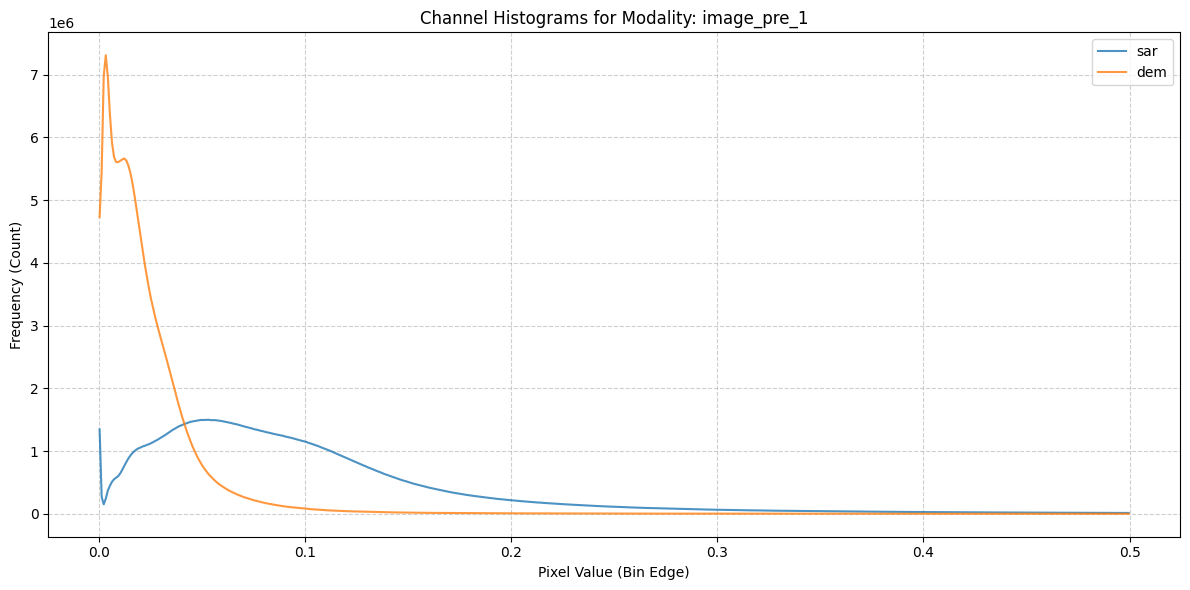

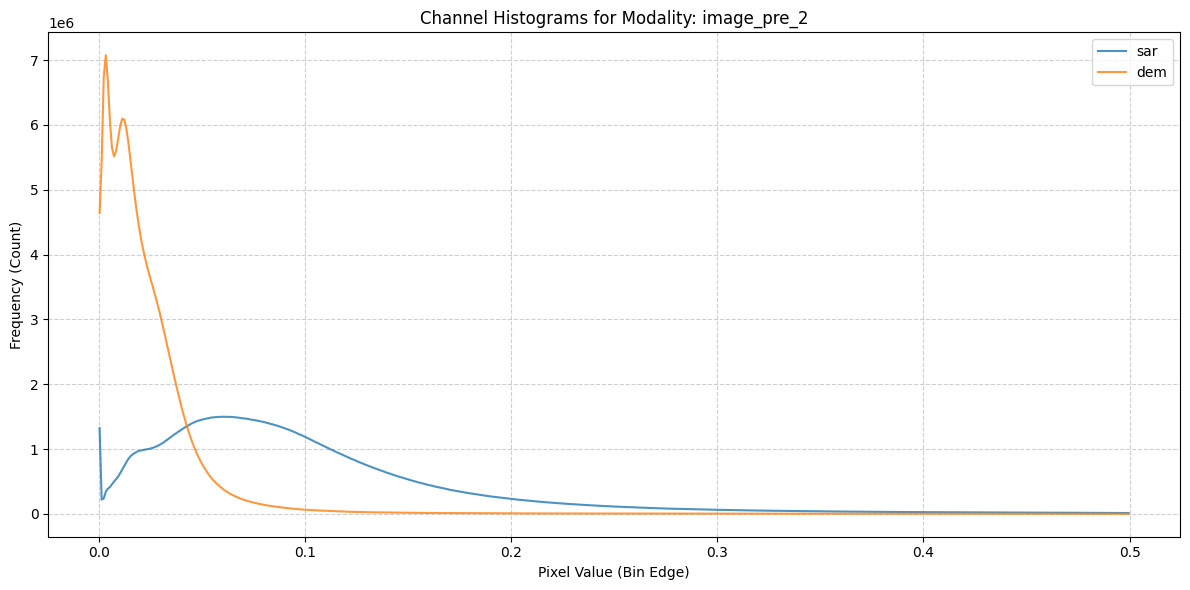

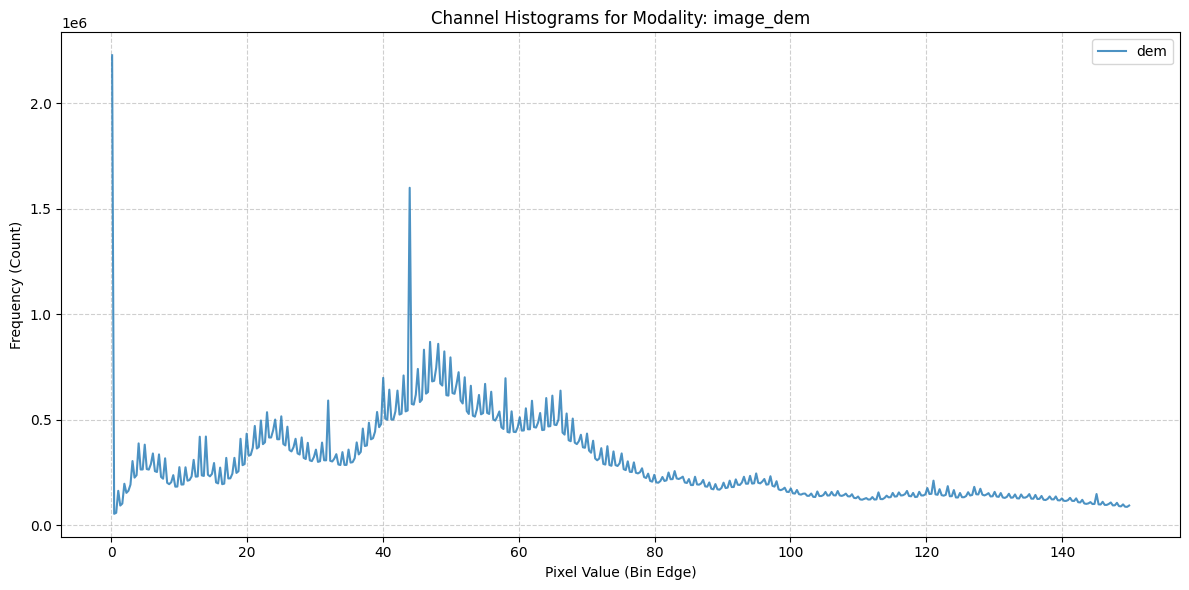

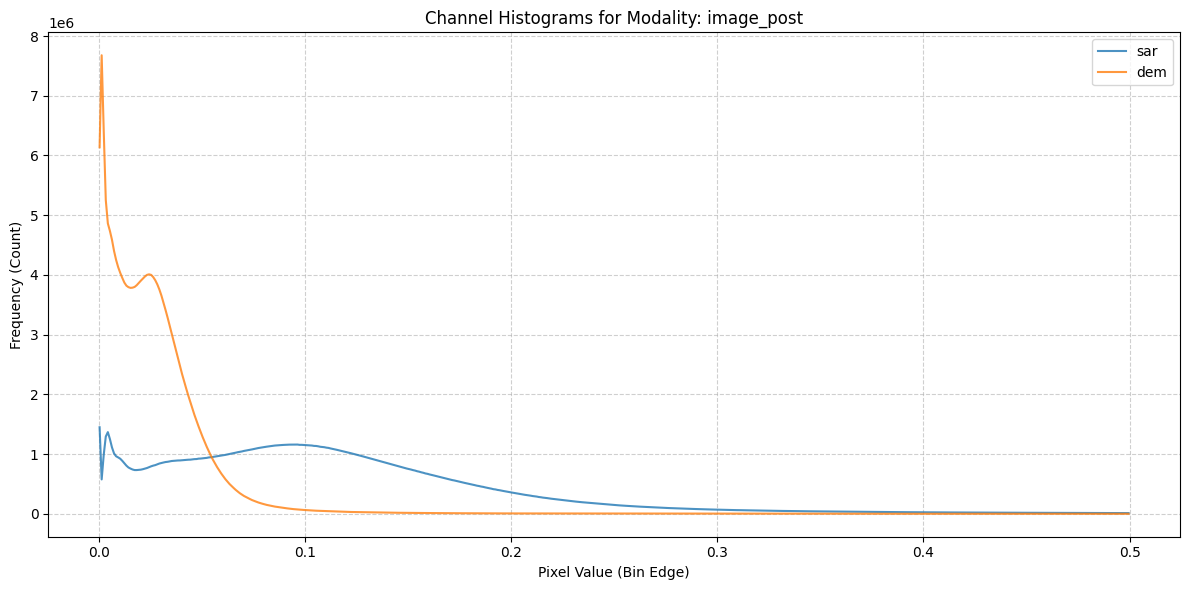

In [4]:
fig = plot_channel_histograms(STATS_SATMAE_PATH)

### Raw Batch Statistics

[<Figure size 1200x500 with 1 Axes>,
 <Figure size 1200x500 with 1 Axes>,
 <Figure size 1200x500 with 1 Axes>,
 <Figure size 1200x500 with 1 Axes>]

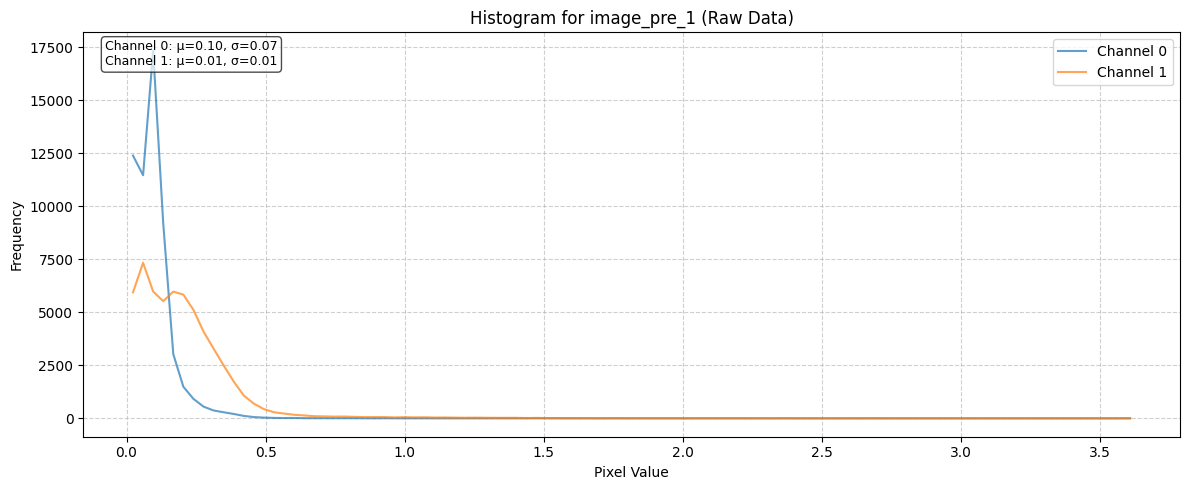

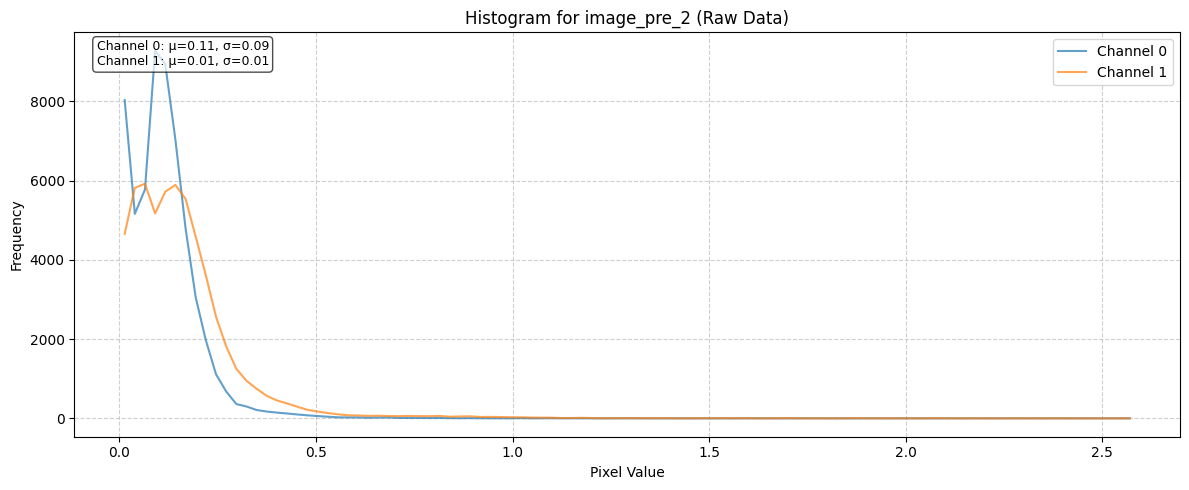

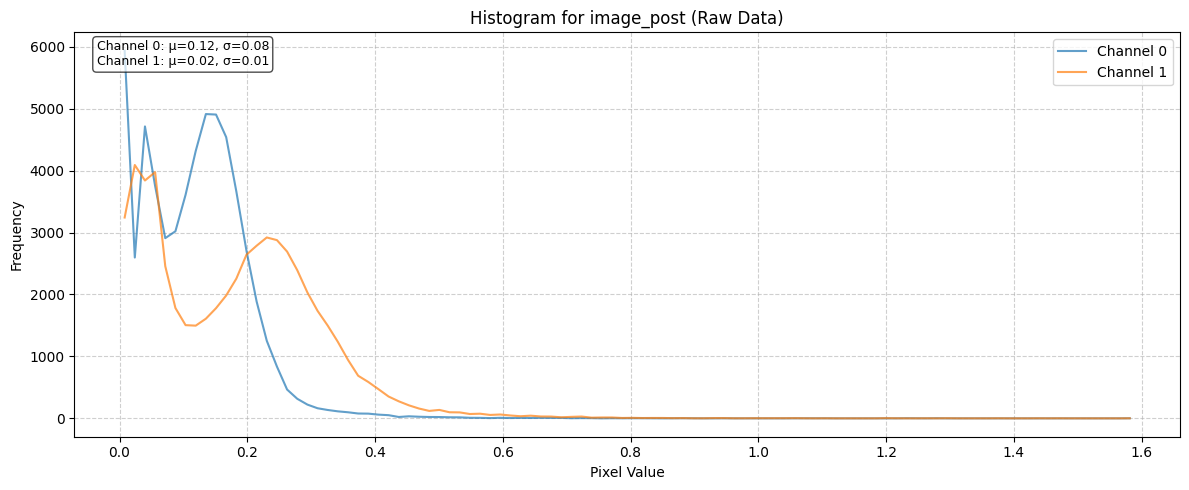

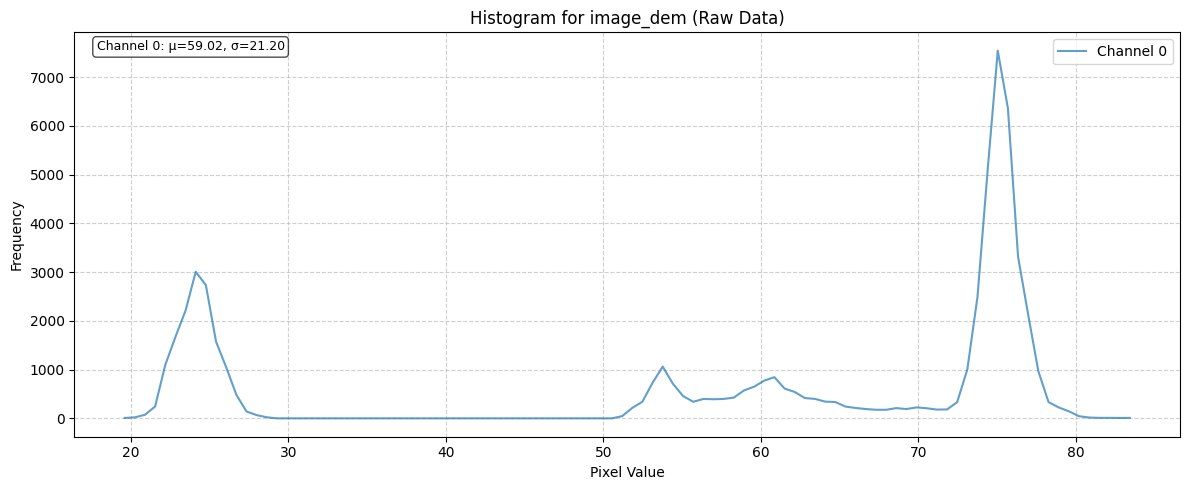

In [5]:
# Get a batch of data from the dataloader
train_dataloader = datamodule.train_dataloader()
raw_batch = next(iter(train_dataloader))

raw_batch_stats = compute_batch_histograms(raw_batch, n_bins=100)


raw_figs = plot_batch_histograms(
    raw_batch_stats, band_order, title_suffix=" (Raw Data)"
)
raw_figs

### Effect of Normalization Schemes

In [6]:
zscore_normalizer = ZScoreNormalizer(STATS_CLIP_RESCALE_PATH, band_order)
satmae_normalizer = SatMAENormalizer(STATS_SATMAE_PATH, band_order)

ValueError: Band 'vv' not found in normalization statistics (means/stds).

In [ ]:
norm_fig, normalized_batches = compare_normalization_methods(
    raw_batch, [zscore_normalizer, satmae_normalizer], datamodule
)

## Visualize Batch

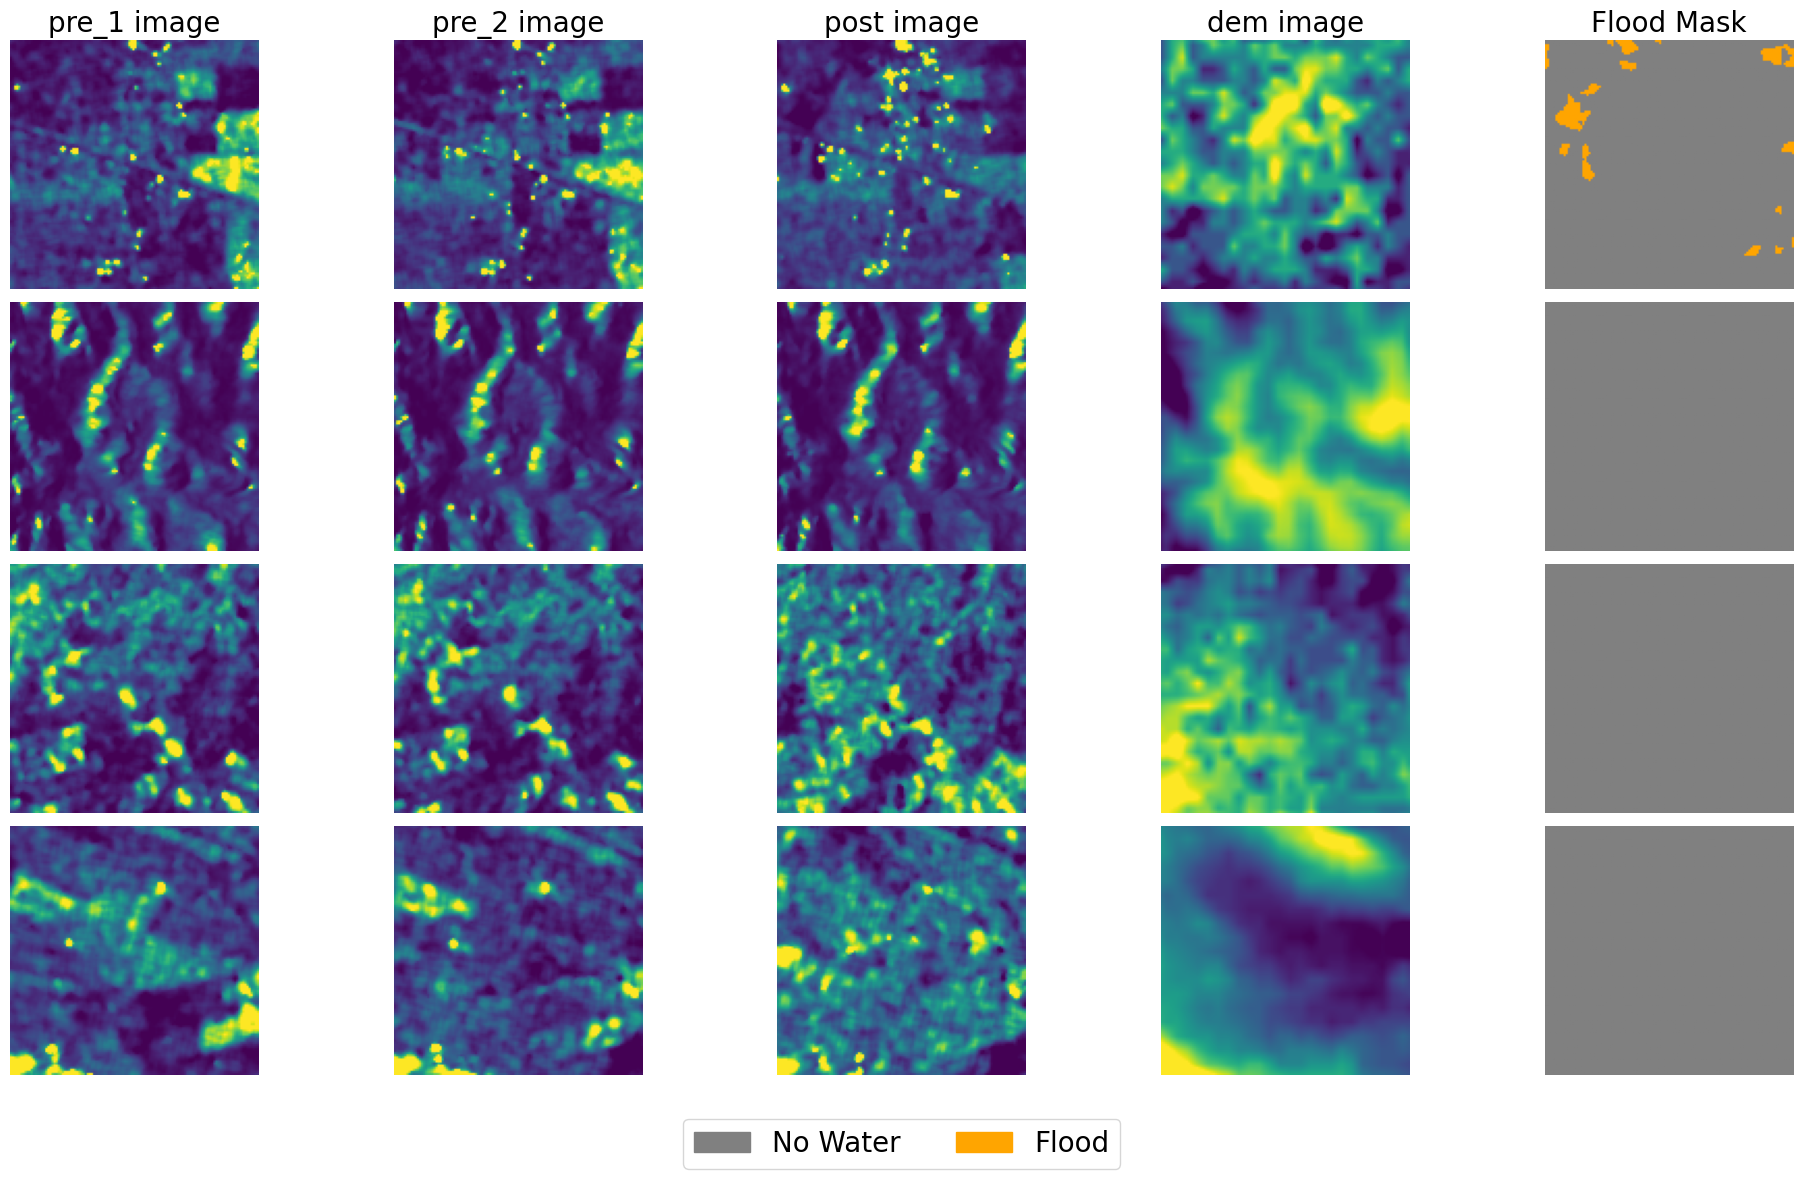

In [7]:
fig, batch = datamodule.visualize_batch()